# TASK-1: Natural Gas Data price modelling

### Goals:
- ***Analyze the data to estimate the purchase price of gas at any date in the past and extrapolate it for one year into the future.***
- ***find patterns and consider what factors might cause the price of natural gas to vary.***

In [52]:
#loading the neccessary libraries in usage
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [53]:
#load the dataset
data = pd.read_csv("natural_gas_data.csv")
data['Dates']

0     10/31/20
1     11/30/20
2     12/31/20
3      1/31/21
4      2/28/21
5      3/31/21
6      4/30/21
7      5/31/21
8      6/30/21
9      7/31/21
10     8/31/21
11     9/30/21
12    10/31/21
13    11/30/21
14    12/31/21
15     1/31/22
16     2/28/22
17     3/31/22
18     4/30/22
19     5/31/22
20     6/30/22
21     7/31/22
22     8/31/22
23     9/30/22
24    10/31/22
25    11/30/22
26    12/31/22
27     1/31/23
28     2/28/23
29     3/31/23
30     4/30/23
31     5/31/23
32     6/30/23
33     7/31/23
34     8/31/23
35     9/30/23
36    10/31/23
37    11/30/23
38    12/31/23
39     1/31/24
40     2/29/24
41     3/31/24
42     4/30/24
43     5/31/24
44     6/30/24
45     7/31/24
46     8/31/24
47     9/30/24
Name: Dates, dtype: object

right now the dates are in mm/dd/yyyy format. we will convert it using pandas datetime function to proper dates in order to extract date, month and year separately from the date object.

In [54]:
data['Dates'] = pd.to_datetime(data['Dates'], format="%m/%d/%y")

#extracting month, date and quarter separately as features
data['Month'] = data['Dates'].dt.month
data['Year'] = data['Dates'].dt.year
data['Quarter'] = data['Dates'].dt.quarter

#we add quarter feature here to use instead of month. since the dataset is small, having multiple categories (12 months) will result in more chances of overfitting than in having 4 categories i.e. 4 quarters
#that way we can have prediction in terms of which quarter had higher pricing than by having 'Jan=high, Feb=Low...' etc

In [55]:
data

,Dates,Prices,Month,Year,Quarter
0,2020-10-31,10.10,10,2020,4
1,2020-11-30,10.30,11,2020,4
2,2020-12-31,11.00,12,2020,4
3,2021-01-31,10.90,1,2021,1
4,2021-02-28,10.90,2,2021,1
5,2021-03-31,10.90,3,2021,1
6,2021-04-30,10.40,4,2021,2
7,2021-05-31,9.84,5,2021,2
8,2021-06-30,10.00,6,2021,2
9,2021-07-31,10.10,7,2021,3


data is already in the ascending order of year. Since the prediction function is a function of time in this case, we will assign a time index to each date.

In [56]:
data['TimeIndex'] = range(len(data))
data

,Dates,Prices,Month,Year,Quarter,TimeIndex
0,2020-10-31,10.10,10,2020,4,0
1,2020-11-30,10.30,11,2020,4,1
2,2020-12-31,11.00,12,2020,4,2
3,2021-01-31,10.90,1,2021,1,3
4,2021-02-28,10.90,2,2021,1,4
5,2021-03-31,10.90,3,2021,1,5
6,2021-04-30,10.40,4,2021,2,6
7,2021-05-31,9.84,5,2021,2,7
8,2021-06-30,10.00,6,2021,2,8
9,2021-07-31,10.10,7,2021,3,9


In [57]:
#setting feature 'Dates' as index
data.set_index("Dates", inplace=True)

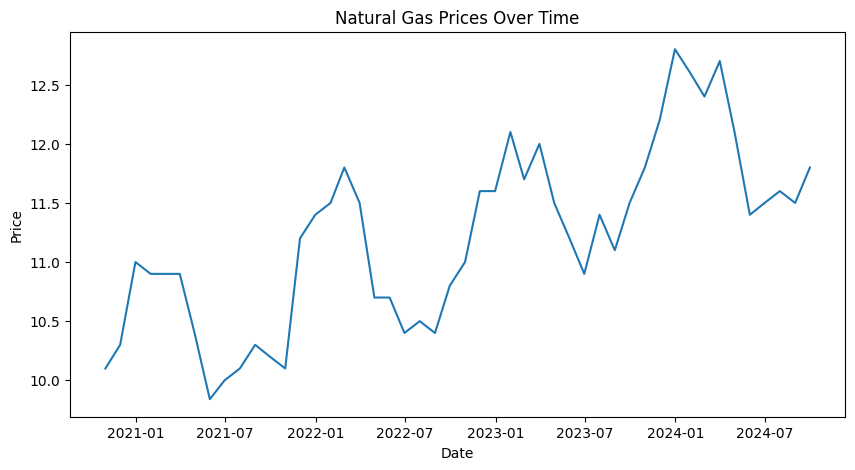

In [58]:
#we first visualize the graph of dates vs prices

plt.figure(figsize=(10,5))
plt.plot(data.index, data["Prices"])

plt.title("Natural Gas Prices Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

we see that the prices are highest in a year during the months of jan, feb and dec. this means that winter demand causes the prices of hike in each year.
now we know that q1 should be high in a year, now we need to check if that is the case for all the quarters and then we need to check if it is the case for the respective quarters in each year

Quarter
1    11.750000
2    10.886667
3    10.933333
4    11.258333
Name: Prices, dtype: float64


Text(0.5, 1.0, 'average price per quarter')

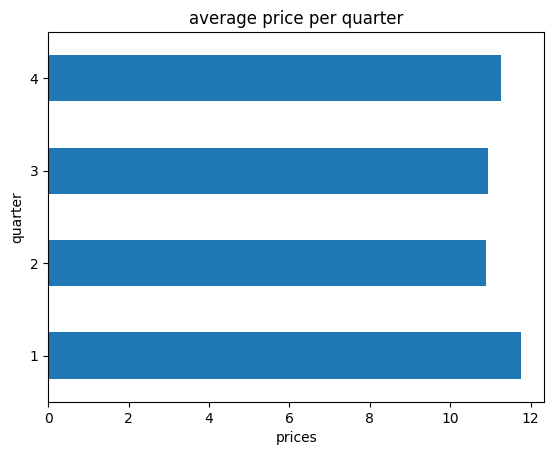

In [59]:
quarter_avg = data.groupby('Quarter')["Prices"].mean()
print(quarter_avg)
#plotting the average quarter prices
quarter_avg.plot(kind='barh')
plt.xlabel('prices')
plt.ylabel('quarter')
plt.title('average price per quarter')

on broad - q1 has highest price of all. we need to check if this is the case in all years given in the data


Year  Quarter
2020  4          10.466667
2021  1          10.900000
      2          10.080000
      3          10.200000
      4          10.900000
2022  1          11.600000
      2          10.600000
      3          10.566667
      4          11.400000
2023  1          11.933333
      2          11.200000
      3          11.333333
      4          12.266667
2024  1          12.566667
      2          11.666667
      3          11.633333
Name: Prices, dtype: float64


Text(0, 0.5, 'quarter')

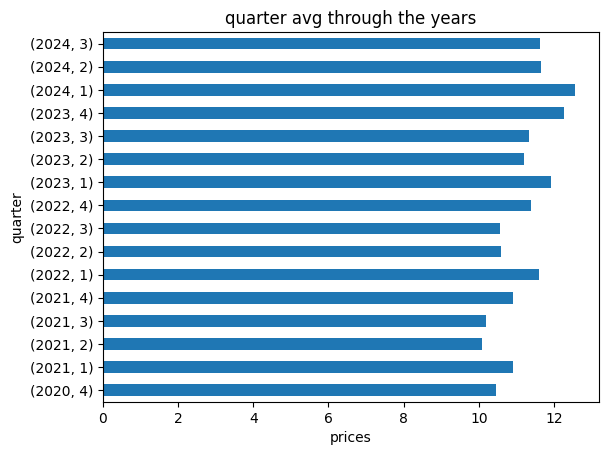

In [60]:
quarter_avg2=data.groupby(["Year", "Quarter"])["Prices"].mean()
print(quarter_avg2)
#plotting the above findings
quarter_avg2.plot(kind='barh')
plt.title('quarter avg through the years')
plt.xlabel('prices')
plt.ylabel('quarter')


we see that q1 is highest in all the years 2021, 2022, 2023, and 2024 and q4 relatively higher than other quarters after q1. we can conclude winter demand and storage inventory levels in the winter season (source -US energy information administration (EIA) https://www.google.com/url?sa=t&source=web&rct=j&opi=89978449&url=https://www.eia.gov/energyexplained/natural-gas/factors-affecting-natural-gas-prices.php&ved=2ahUKEwib3qG80Y2UAxWNxjgGHUAzKUEQFnoECBkQAQ&usg=AOvVaw3LMlKWCQ_E6Xvo6ee2ksJH) 


Therefore, quarter-based seasonality should be included as an important feature in forecasting future natural gas prices.

Month
1     11.775
2     11.700
3     11.775
4     11.175
5     10.785
6     10.700
7     10.900
8     10.825
9     11.075
10    10.750
11    11.325
12    11.700
Name: Prices, dtype: float64


Text(0.5, 0, 'prices')

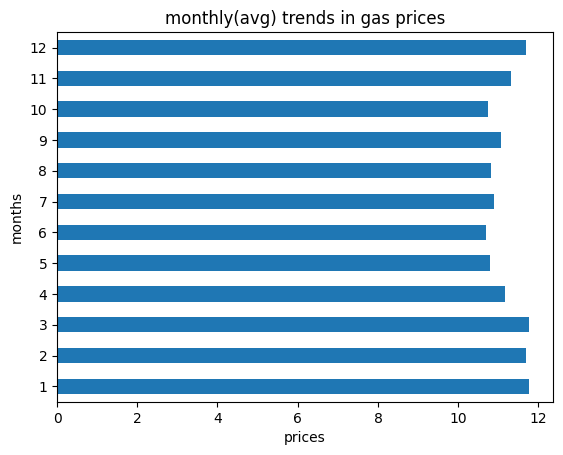

In [61]:
#now we gotta check monthly effect
monthly_avg = data.groupby("Month")["Prices"].mean()
print(monthly_avg)

#plotting the above data
monthly_avg.plot(kind = 'barh')
plt.title('monthly(avg) trends in gas prices')
plt.ylabel('months')
plt.xlabel('prices')

this concretes our findings, we see on an average throughout the 5 years of data presented to us, january, february, march and december - the core winter months - have the highest gas prices.
this further concretes the proof that winter months had the highest gas prices due to explained reasons above.

# EDA Conclusion
From the time-series visualization and the quarter-wise/month-wise seasonal analysis, it is observed that **natural gas prices are highest during the winter months, mainly in Q1 (January–March) and Q4 (October–December).**
This indicates a **strong seasonal pattern in the dataset.**
The primary reason is likely increased winter demand, as natural gas consumption rises significantly for heating purposes during colder months. Higher demand creates upward pressure on prices.
In addition, storage levels also play an important role. During colder seasons, gas inventories are used more heavily, and concerns about supply availability can further increase prices. Lower storage availability or expected shortages often lead to higher purchase prices.
Since this pattern repeats across multiple years, it suggests that these fluctuations are not random but are driven by consistent seasonal demand and storage-related market behavior.
Therefore, ***seasonality (especially winter demand and storage effects) is a major factor influencing natural gas price movements and must be considered in forecasting future prices.***

In [62]:
#prediction 
#first we need to interpolate the data, here we have chosen to use 'Dates' feature as our index.
data.asfreq('D')
data['Prices'] = data['Prices'].interpolate(method='linear')


***interpolating now helps us later when we are asked to predict price of a date which is in between two data points in the dataset***

In [67]:
quarter_dummies = pd.get_dummies(
    data["Quarter"],
    prefix="Quarter",
    drop_first=True
)

data = pd.concat([data, quarter_dummies], axis=1)

print(data.head())

# ---------------------------------
# Features for regression
# ---------------------------------

X = data[
    [
        "TimeIndex",
        "Quarter_2",
        "Quarter_3",
        "Quarter_4"
    ]
]

y = data["Prices"]

# ---------------------------------
# Train-test split
# ---------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

# ---------------------------------
# Train model
# ---------------------------------

model = LinearRegression()
model.fit(X_train, y_train)

# ---------------------------------
# Predictions
# ---------------------------------

predictions = model.predict(X_test)

# ---------------------------------
# Results
# ---------------------------------

print("\nIntercept:")
print(model.intercept_)

print("\nCoefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature} : {coef}")

print("\nMAE:")
print(mean_absolute_error(y_test, predictions))

print("\nRMSE:")
print(mean_squared_error(y_test, predictions) ** 0.5)

            Prices  Month  Year  Quarter  TimeIndex  Quarter_2  Quarter_3  \
Dates                                                                       
2020-10-31    10.1     10  2020        4          0      False      False   
2020-11-30    10.3     11  2020        4          1      False      False   
2020-12-31    11.0     12  2020        4          2      False      False   
2021-01-31    10.9      1  2021        1          3      False      False   
2021-02-28    10.9      2  2021        1          4      False      False   

            Quarter_4  
Dates                  
2020-10-31       True  
2020-11-30       True  
2020-12-31       True  
2021-01-31      False  
2021-02-28      False  

Intercept:
10.764429791214567

Coefficients:
TimeIndex : 0.04458424916020108
Quarter_2 : -0.9848638585917233
Quarter_3 : -1.0452832727390018
Quarter_4 : -0.4163395494362192

MAE:
0.2505831616877739

RMSE:
0.32444138621952395


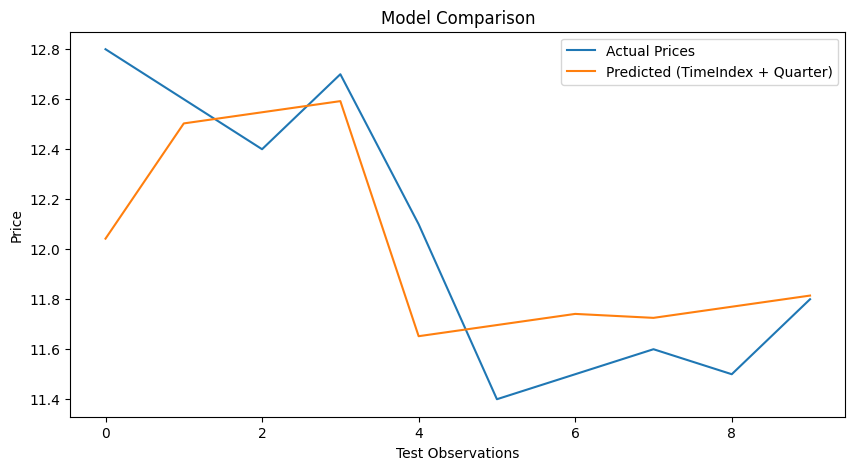

In [70]:
plt.figure(figsize=(10,5))

plt.plot(y_test.values, label="Actual Prices")
plt.plot(predictions, label="Predicted (TimeIndex + Quarter)")

plt.title("Model Comparison")
plt.xlabel("Test Observations")
plt.ylabel("Price")
plt.legend()
plt.show()

        Dates  TimeIndex  Quarter  Quarter_2  Quarter_3  Quarter_4  \
0  2024-10-31         48        4      False      False       True   
1  2024-11-30         49        4      False      False       True   
2  2024-12-31         50        4      False      False       True   
3  2025-01-31         51        1      False      False      False   
4  2025-02-28         52        1      False      False      False   
5  2025-03-31         53        1      False      False      False   
6  2025-04-30         54        2       True      False      False   
7  2025-05-31         55        2       True      False      False   
8  2025-06-30         56        2       True      False      False   
9  2025-07-31         57        3      False       True      False   
10 2025-08-31         58        3      False       True      False   
11 2025-09-30         59        3      False       True      False   

    PredictedPrice  
0        12.488134  
1        12.532718  
2        12.577303  
3    

/var/folders/ll/l0t2714j2sddm7tb5lxttf4m0000gn/T/ipykernel_14789/1444391645.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(start="2024-10-31", periods=12, freq='M')


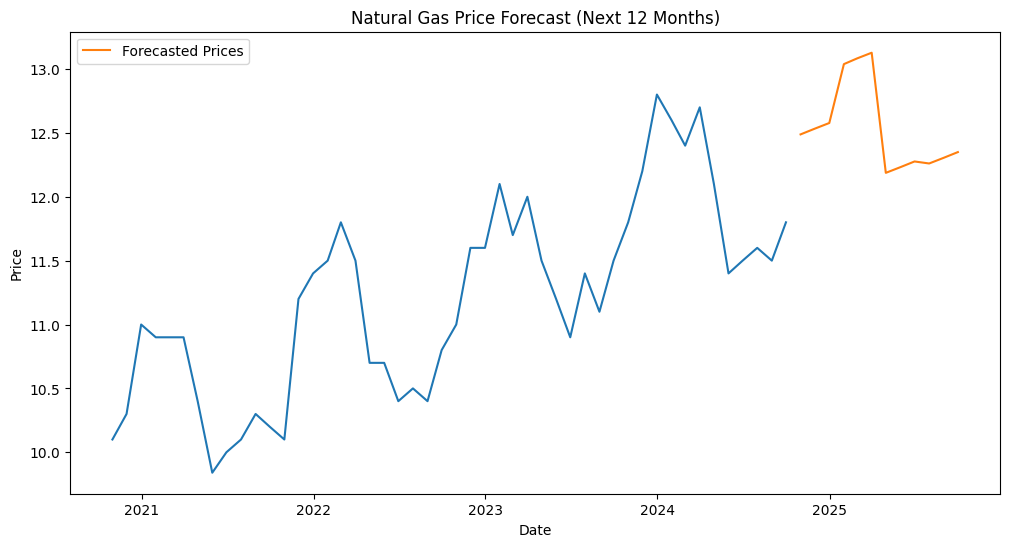

In [74]:
#Future forecasting (1 year into future)
future_dates = pd.date_range(start="2024-10-31", periods=12, freq='M')
future_df = pd.DataFrame({'Dates':future_dates})

#creating time index for future_dates
future_df["TimeIndex"]= range(len(data), len(data)+12)
future_df["Quarter"]= future_df['Dates'].dt.quarter

# One-hot encode Quarter
future_dummies = pd.get_dummies(future_df["Quarter"], prefix="Quarter", drop_first=True)
future_df = pd.concat([future_df, future_dummies],axis=1)

for col in ["Quarter_2", "Quarter_3", "Quarter_4"]:
    if col not in future_df.columns:
        future_df[col] = 0

# Keep same feature order
future_X = future_df[["TimeIndex","Quarter_2","Quarter_3","Quarter_4"]]
future_df["PredictedPrice"] = model.predict(future_X)
print(future_df)


#plot historical vs future
plt.figure(figsize=(12,6))
plt.plot(data.index, data["Prices"])
plt.plot(future_df["Dates"],future_df["PredictedPrice"],label="Forecasted Prices")
plt.title("Natural Gas Price Forecast (Next 12 Months)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

# **Prediction Conclusion**

Using linear regression with TimeIndex and one-hot encoded Quarter as features, the natural gas prices were forecasted for the next 12 months (October 2024 to September 2025).
The model shows a **clear long-term upward trend**, indicating that natural gas prices are expected to gradually increase over time. The positive TimeIndex coefficient confirms that the **average price rises slightly each month.**
The forecast also preserves the strong seasonal pattern observed in the historical data. Prices are predicted to be highest during Q1 (January–March), followed by relatively high values in Q4 (October–December), while Q2 and Q3 show comparatively lower prices. This supports the earlier finding that winter demand and storage-related supply pressures significantly influence pricing.
**The highest predicted prices occur during early 2025, where values rise above 13, while mid-year prices fall closer to 12.2–12.3 before increasing again.**
This indicates that natural gas pricing is influenced by both:
- Long-term market trend (gradual yearly increase)
- Seasonal demand cycles (especially winter demand and storage effects)
Therefore, the model suggests that future natural gas prices will continue following a seasonal winter-peak pattern with an overall upward trend.